In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
data = pd.read_csv('E:/Machine Learninng/Project/fraud-detection/data/creditcard.csv')

In [3]:
data

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
284802,172786.0,-11.881118,10.071785,-9.834783,-2.066656,-5.364473,-2.606837,-4.918215,7.305334,1.914428,...,0.213454,0.111864,1.014480,-0.509348,1.436807,0.250034,0.943651,0.823731,0.77,0
284803,172787.0,-0.732789,-0.055080,2.035030,-0.738589,0.868229,1.058415,0.024330,0.294869,0.584800,...,0.214205,0.924384,0.012463,-1.016226,-0.606624,-0.395255,0.068472,-0.053527,24.79,0
284804,172788.0,1.919565,-0.301254,-3.249640,-0.557828,2.630515,3.031260,-0.296827,0.708417,0.432454,...,0.232045,0.578229,-0.037501,0.640134,0.265745,-0.087371,0.004455,-0.026561,67.88,0
284805,172788.0,-0.240440,0.530483,0.702510,0.689799,-0.377961,0.623708,-0.686180,0.679145,0.392087,...,0.265245,0.800049,-0.163298,0.123205,-0.569159,0.546668,0.108821,0.104533,10.00,0


In [4]:
data.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [5]:
df = data.copy()

In [6]:
df.shape

(284807, 31)

## Basic Information
- Features are principal components obtained after PCA transformation.  
V1–V28 are not raw transaction features, they are transformed, anonymized features

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

- There are no missing values in any columns.  

- All columns are `float` and output column contains `binary` output i.e. 0 & 1.

In [8]:
df.describe()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,284807.000000,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,...,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,284807.000000,284807.000000
mean,94813.859575,1.175161e-15,3.384974e-16,-1.379537e-15,2.094852e-15,1.021879e-15,1.494498e-15,-5.620335e-16,1.149614e-16,-2.414189e-15,...,1.628620e-16,-3.576577e-16,2.618565e-16,4.473914e-15,5.109395e-16,1.686100e-15,-3.661401e-16,-1.227452e-16,88.349619,0.001727
std,47488.145955,1.958696e+00,1.651309e+00,1.516255e+00,1.415869e+00,1.380247e+00,1.332271e+00,1.237094e+00,1.194353e+00,1.098632e+00,...,7.345240e-01,7.257016e-01,6.244603e-01,6.056471e-01,5.212781e-01,4.822270e-01,4.036325e-01,3.300833e-01,250.120109,0.041527
min,0.000000,-5.640751e+01,-7.271573e+01,-4.832559e+01,-5.683171e+00,-1.137433e+02,-2.616051e+01,-4.355724e+01,-7.321672e+01,-1.343407e+01,...,-3.483038e+01,-1.093314e+01,-4.480774e+01,-2.836627e+00,-1.029540e+01,-2.604551e+00,-2.256568e+01,-1.543008e+01,0.000000,0.000000
25%,54201.500000,-9.203734e-01,-5.985499e-01,-8.903648e-01,-8.486401e-01,-6.915971e-01,-7.682956e-01,-5.540759e-01,-2.086297e-01,-6.430976e-01,...,-2.283949e-01,-5.423504e-01,-1.618463e-01,-3.545861e-01,-3.171451e-01,-3.269839e-01,-7.083953e-02,-5.295979e-02,5.600000,0.000000
50%,84692.000000,1.810880e-02,6.548556e-02,1.798463e-01,-1.984653e-02,-5.433583e-02,-2.741871e-01,4.010308e-02,2.235804e-02,-5.142873e-02,...,-2.945017e-02,6.781943e-03,-1.119293e-02,4.097606e-02,1.659350e-02,-5.213911e-02,1.342146e-03,1.124383e-02,22.000000,0.000000
75%,139320.500000,1.315642e+00,8.037239e-01,1.027196e+00,7.433413e-01,6.119264e-01,3.985649e-01,5.704361e-01,3.273459e-01,5.971390e-01,...,1.863772e-01,5.285536e-01,1.476421e-01,4.395266e-01,3.507156e-01,2.409522e-01,9.104512e-02,7.827995e-02,77.165000,0.000000
max,172792.000000,2.454930e+00,2.205773e+01,9.382558e+00,1.687534e+01,3.480167e+01,7.330163e+01,1.205895e+02,2.000721e+01,1.559499e+01,...,2.720284e+01,1.050309e+01,2.252841e+01,4.584549e+00,7.519589e+00,3.517346e+00,3.161220e+01,3.384781e+01,25691.160000,1.000000


In [9]:
df['Class'].value_counts()

Class
0    284315
1       492
Name: count, dtype: int64

- If a model predicts all transactions as non-fraud,accuracy = 99.83% & recall = 0 but it is of no use & it is not acceptable.

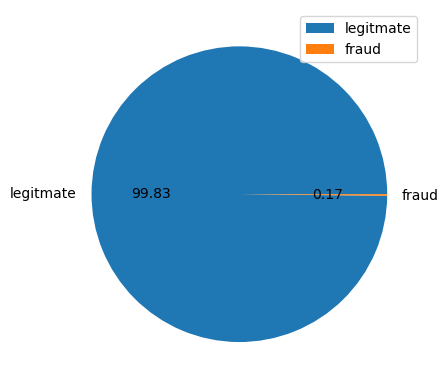

In [10]:
plt.pie(df['Class'].value_counts(),labels=['legitmate','fraud'],autopct="%.2f")
plt.legend()
plt.show()

In [11]:
## train test split 
X = df.iloc[:,:-1]
y = df.iloc[:,-1]

The `stratify` parameter in train_test_split ensures that the training and testing datasets maintain the same class distribution as the original dataset

In [12]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,random_state = 2,test_size = 0.2,stratify=y)


In [13]:
X_test.shape

(56962, 30)

Dummy Classifier

In [14]:
from sklearn.dummy import DummyClassifier

In [15]:
dummy = DummyClassifier(strategy='most_frequent')
dummy.fit(X_train,y_train)


,strategy,'most_frequent'
,random_state,None
,constant,None


In [16]:
y_pred = dummy.predict(X_test)
y_prob = dummy.predict_proba(X_test)[:,1]

In [17]:
from sklearn.metrics import accuracy_score,precision_score,recall_score,f1_score,roc_auc_score,confusion_matrix,ConfusionMatrixDisplay

In [18]:
print("Acuracy : ",accuracy_score(y_test,y_pred))
print("Recall : ",recall_score(y_test,y_pred))
print("Precision : ",precision_score(y_test,y_pred))
print("F1 Score : ",f1_score(y_test,y_pred))
print("ROC_AUC :",roc_auc_score(y_test,y_prob) )



Acuracy :  0.9982795547909132
Recall :  0.0
Precision :  0.0
F1 Score :  0.0
ROC_AUC : 0.5


c:\ProgramData\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


In [19]:
cm = confusion_matrix(y_test,y_pred)
cm

array([[56864,     0],
       [   98,     0]])

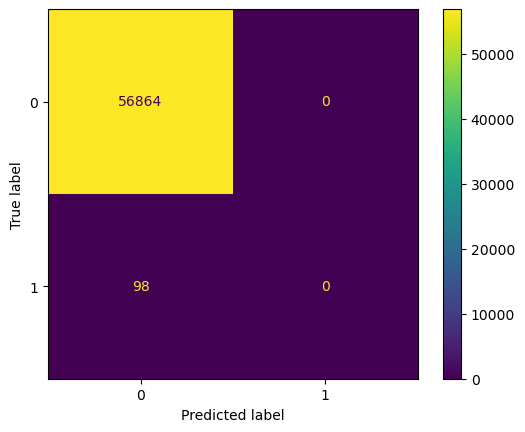

In [20]:
obj = ConfusionMatrixDisplay(cm)
obj.plot()

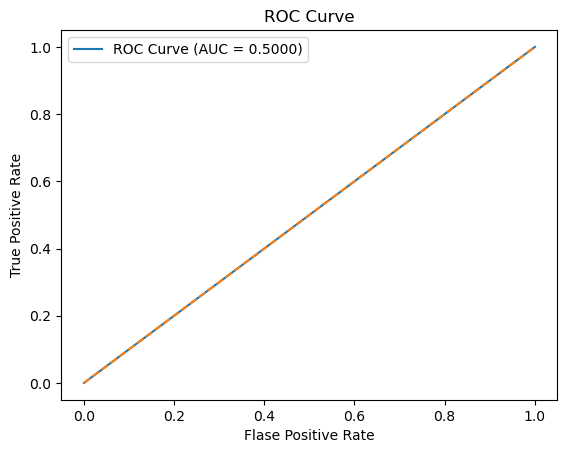

In [21]:
from sklearn.metrics import roc_curve,roc_auc_score
# roc values
fpr,tpr,threshold = roc_curve(y_test,y_prob)

# AUC score

roc_auc = roc_auc_score(y_test,y_prob)

plt.figure()
plt.plot(fpr,tpr,label=f"ROC Curve (AUC = {roc_auc:.4f})")
plt.plot([0,1],[0,1],linestyle='--')
plt.xlabel("Flase Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

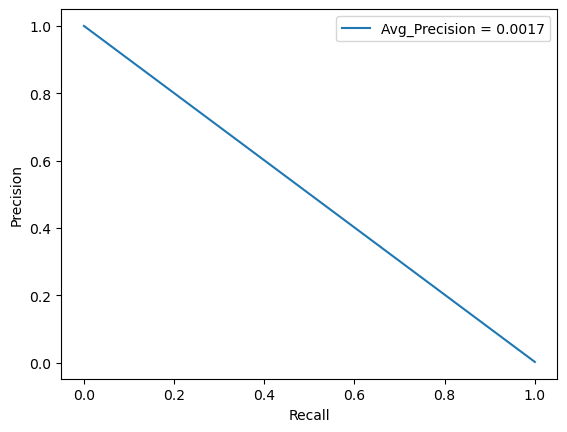

In [22]:
from sklearn.metrics import precision_recall_curve,average_precision_score

precision , recall, threshold = precision_recall_curve(y_test,y_prob)

avg_prec_score = average_precision_score(y_test,y_prob)

plt.figure()
plt.plot(recall,precision,label = f"Avg_Precision = {avg_prec_score:.4f}")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.legend()
plt.show()

Baseline Model - Logistic Regression

In [23]:
# scaling the amount column 

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train['Amount'] = scaler.fit_transform(X_train[['Amount']])
X_test['Amount'] = scaler.transform(X_test[['Amount']])

In [24]:

X_train['Time'] = scaler.fit_transform(X_train[['Time']])
X_test['Time'] = scaler.transform(X_test[['Time']])

In [25]:
from sklearn.linear_model import LogisticRegression
log_reg_model = LogisticRegression(max_iter=1000)
log_reg_model.fit(X_train,y_train)


,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [26]:
y_pred = log_reg_model.predict(X_test)
y_prob = log_reg_model.predict_proba(X_test)[:,1]

In [27]:
print("Acuracy : ",accuracy_score(y_test,y_pred))
print("Recall : ",recall_score(y_test,y_pred))
print("Precision : ",precision_score(y_test,y_pred))
print("F1 Score : ",f1_score(y_test,y_pred))
print("ROC_AUC :",roc_auc_score(y_test,y_prob) )
cm = confusion_matrix(y_test,y_pred)
cm


Acuracy :  0.9993504441557529
Recall :  0.6938775510204082
Precision :  0.9066666666666666
F1 Score :  0.7861271676300579
ROC_AUC : 0.9921554686871934


array([[56857,     7],
       [   30,    68]])

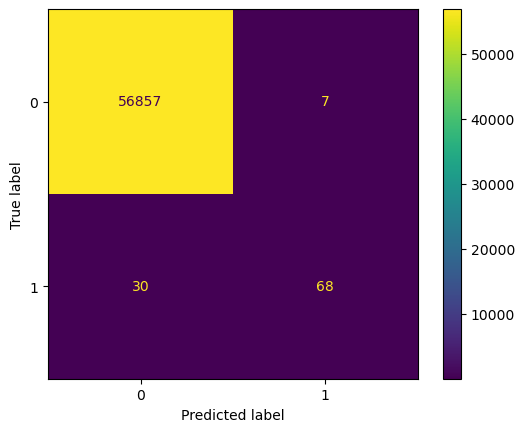

In [28]:
obj = ConfusionMatrixDisplay(cm)
obj.plot()

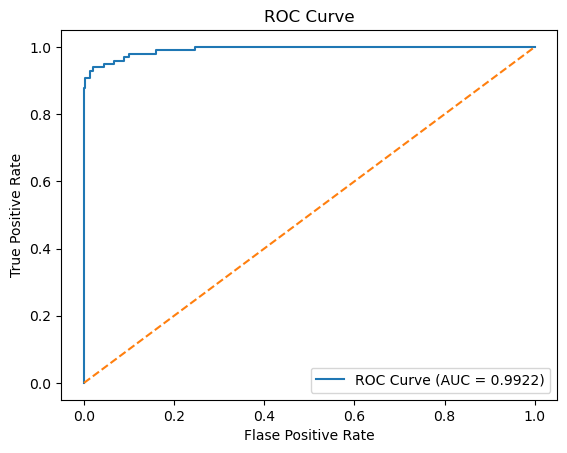

In [29]:
# roc values
fpr,tpr,threshold = roc_curve(y_test,y_prob)

# AUC score

roc_auc = roc_auc_score(y_test,y_prob)

plt.figure()
plt.plot(fpr,tpr,label=f"ROC Curve (AUC = {roc_auc:.4f})")
plt.plot([0,1],[0,1],linestyle='--')
plt.xlabel("Flase Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

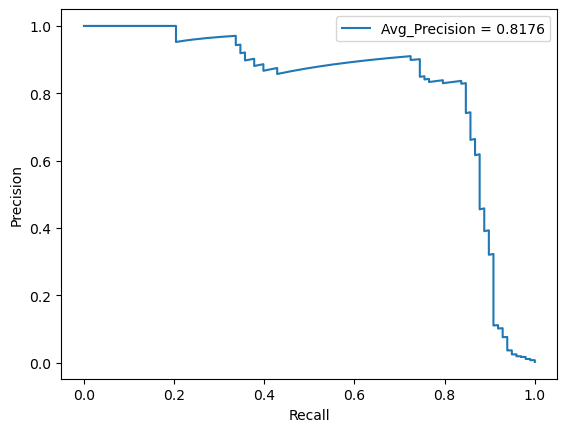

In [30]:
from sklearn.metrics import precision_recall_curve,average_precision_score

precision , recall, threshold = precision_recall_curve(y_test,y_prob)

avg_prec_score = average_precision_score(y_test,y_prob)

plt.figure()
plt.plot(recall,precision,label = f"Avg_Precision = {avg_prec_score:.4f}")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.legend()
plt.show()

In [31]:
# checking metrics for different thresholds
thresholds = np.linspace(0.1,0.9,81)
best_t = 0
best_f1 = 0

for t in thresholds:
    y_pred_t = (y_prob >= t).astype(int)
    f1 = f1_score(y_test, y_pred_t)

    if f1 > best_f1:
        best_f1 = f1
        best_t = t

print("Best threshold:", best_t)
print("Best F1:", best_f1)
    

Best threshold: 0.1
Best F1: 0.8247422680412371


In [32]:
best_t = 0
best_recall = 0

for t in thresholds:
    y_pred_t = (y_prob >= t).astype(int)
    prec = precision_score(y_test, y_pred_t)
    reca = recall_score(y_test, y_pred_t)

    if prec >= 0.8 and reca > best_recall:
        best_recall = reca
        best_t = t

print("Best threshold:", best_t)
print("Best recall:", best_recall)

Best threshold: 0.1
Best recall: 0.8163265306122449


In [33]:
# if FN costs = 5000 & FP cost = 200
best_t = 0
lowest_cost = float("inf")

for t in thresholds:
    y_pred_t = (y_prob >= t).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred_t).ravel()

    cost = fn * 5000 + fp * 200

    if cost < lowest_cost:
        lowest_cost = cost
        best_t = t

print("Best threshold:", best_t)
print("Lowest cost : ",lowest_cost)

Best threshold: 0.1
Lowest cost :  93200


In [34]:
y_pred_t = (y_prob >= 0.1).astype(int)
cm = confusion_matrix(y_test,y_pred_t)
cm

array([[56848,    16],
       [   18,    80]])

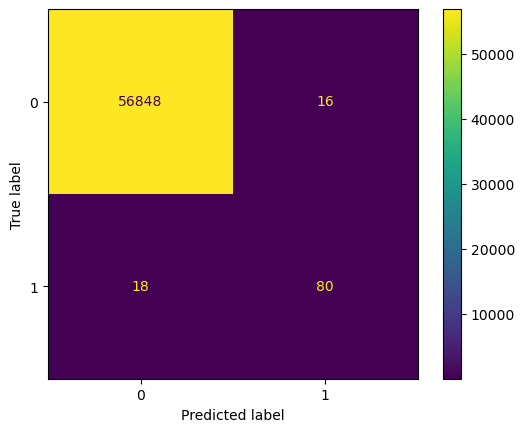

In [35]:
obj = ConfusionMatrixDisplay(cm)
obj.plot()

In [ ]:
results = []

for t in thresholds:
    y_pred_t = (y_prob >= t).astype(int)

    precision = precision_score(y_test, y_pred_t, zero_division=0)
    recall = recall_score(y_test, y_pred_t, zero_division=0)
    f1 = f1_score(y_test, y_pred_t, zero_division=0)

    results.append([t, precision, recall, f1])

threshold_df = pd.DataFrame(
    results,
    columns=["Threshold", "Precision", "Recall", "F1"]
)

threshold_df.head()

,Threshold,Precision,Recall,F1
0,0.10,0.833333,0.816327,0.824742
1,0.11,0.831579,0.806122,0.818653
2,0.12,0.835165,0.775510,0.804233
3,0.13,0.835165,0.775510,0.804233
4,0.14,0.833333,0.765306,0.797872


Logistic Regression + class_weight

In [37]:
# using class_weights in LR

weight_log_reg_model = LogisticRegression(class_weight='balanced',max_iter=1000)
weight_log_reg_model.fit(X_train,y_train)
y_pred = weight_log_reg_model.predict(X_test)
y_prob = weight_log_reg_model.predict_proba(X_test)[:,1]

In [38]:
print("Acuracy : ",accuracy_score(y_test,y_pred))
print("Recall : ",recall_score(y_test,y_pred))
print("Precision : ",precision_score(y_test,y_pred))
print("F1 Score : ",f1_score(y_test,y_pred))
print("ROC_AUC :",roc_auc_score(y_test,y_prob) )
cm = confusion_matrix(y_test,y_pred)
cm

Acuracy :  0.97631754503002
Recall :  0.9489795918367347
Precision :  0.06471816283924843
F1 Score :  0.12117263843648209
ROC_AUC : 0.9916853172051037


array([[55520,  1344],
       [    5,    93]])

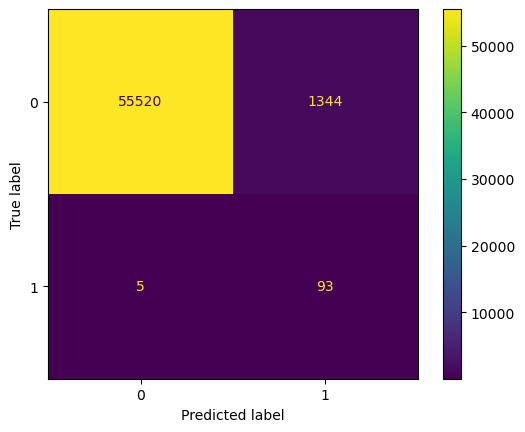

In [39]:
obj = ConfusionMatrixDisplay(cm)
obj.plot()

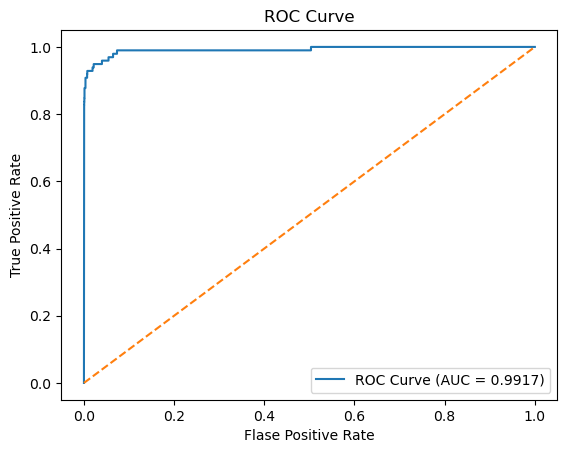

In [40]:
# roc values
fpr,tpr,threshold = roc_curve(y_test,y_prob)

# AUC score

roc_auc = roc_auc_score(y_test,y_prob)

plt.figure()
plt.plot(fpr,tpr,label=f"ROC Curve (AUC = {roc_auc:.4f})")
plt.plot([0,1],[0,1],linestyle='--')
plt.xlabel("Flase Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

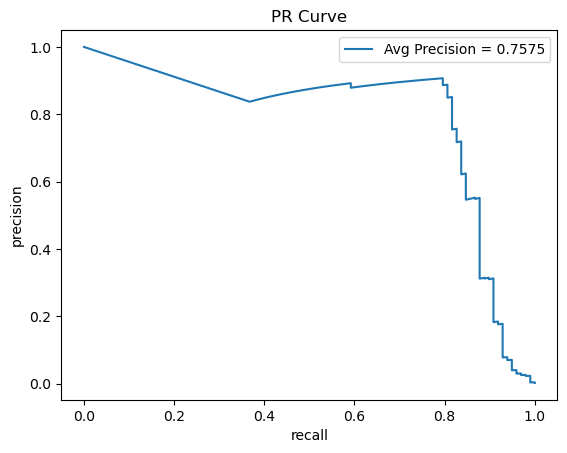

In [41]:
precision , recall , threshold = precision_recall_curve(y_test,y_prob)

avg_prec_score = average_precision_score(y_test,y_prob)

plt.plot(recall,precision,label=f"Avg Precision = {avg_prec_score:.4f}")
plt.xlabel("recall")
plt.ylabel("precision")
plt.title("PR Curve")
plt.legend()
plt.show()

Logistic Regression + under_sampling

In [42]:
from imblearn.under_sampling import RandomUnderSampler

rand_under_sampler = RandomUnderSampler(sampling_strategy='majority',random_state = 42)

X_resampled , y_resampled = rand_under_sampler.fit_resample(X_train,y_train)

In [43]:
X_resampled.shape

(788, 30)

In [44]:

us_log_reg_model = LogisticRegression(max_iter=1000)
us_log_reg_model.fit(X_resampled,y_resampled)
y_pred = us_log_reg_model.predict(X_test)
y_prob = us_log_reg_model.predict_proba(X_test)[:,1]

print("Acuracy : ",accuracy_score(y_test,y_pred))
print("Recall : ",recall_score(y_test,y_pred))
print("Precision : ",precision_score(y_test,y_pred))
print("F1 Score : ",f1_score(y_test,y_pred))
print("ROC_AUC :",roc_auc_score(y_test,y_prob) )
cm = confusion_matrix(y_test,y_pred)
cm

Acuracy :  0.964449984199993
Recall :  0.9489795918367347
Precision :  0.04401325130146711
F1 Score :  0.08412483039348712
ROC_AUC : 0.9893968279489622


array([[54844,  2020],
       [    5,    93]])

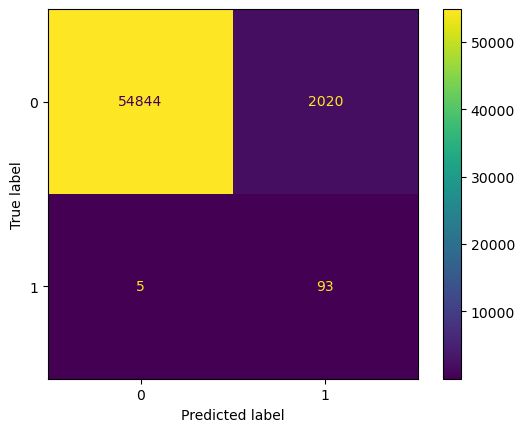

In [45]:
obj = ConfusionMatrixDisplay(cm)
obj.plot()

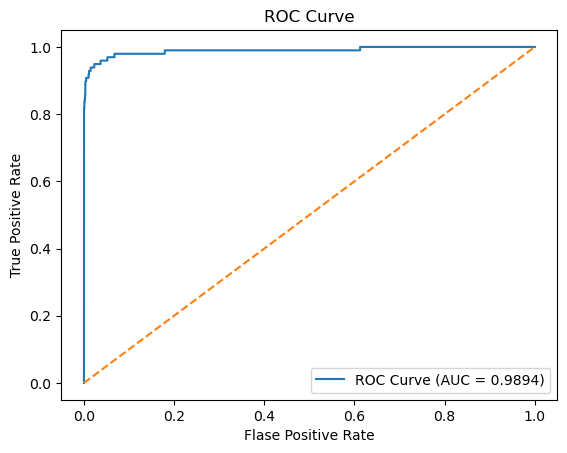

In [46]:
# roc values
fpr,tpr,threshold = roc_curve(y_test,y_prob)

# AUC score

roc_auc = roc_auc_score(y_test,y_prob)

plt.figure()
plt.plot(fpr,tpr,label=f"ROC Curve (AUC = {roc_auc:.4f})")
plt.plot([0,1],[0,1],linestyle='--')
plt.xlabel("Flase Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

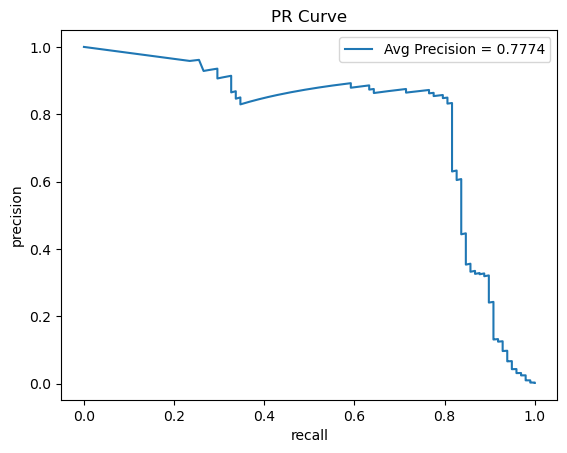

In [47]:
precision , recall , threshold = precision_recall_curve(y_test,y_prob)

avg_prec_score = average_precision_score(y_test,y_prob)

plt.plot(recall,precision,label=f"Avg Precision = {avg_prec_score:.4f}")
plt.xlabel("recall")
plt.ylabel("precision")
plt.title("PR Curve")
plt.legend()
plt.show()

Logistic Regression + SMOTE

In [48]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)

X_resampled, y_resampled = smote.fit_resample(X_train,y_train)

In [49]:
X_resampled.shape

(454902, 30)

In [50]:
smote_log_reg_model = LogisticRegression(max_iter=1000)
smote_log_reg_model.fit(X_resampled,y_resampled)
y_pred = smote_log_reg_model.predict(X_test)
y_prob = smote_log_reg_model.predict_proba(X_test)[:,1]

print("Acuracy : ",accuracy_score(y_test,y_pred))
print("Recall : ",recall_score(y_test,y_pred))
print("Precision : ",precision_score(y_test,y_pred))
print("F1 Score : ",f1_score(y_test,y_pred))
print("ROC_AUC :",roc_auc_score(y_test,y_prob) )
cm = confusion_matrix(y_test,y_pred)
cm

Acuracy :  0.9731575436255749
Recall :  0.9489795918367347
Precision :  0.0575139146567718
F1 Score :  0.10845481049562682
ROC_AUC : 0.9912942121840296


array([[55340,  1524],
       [    5,    93]])

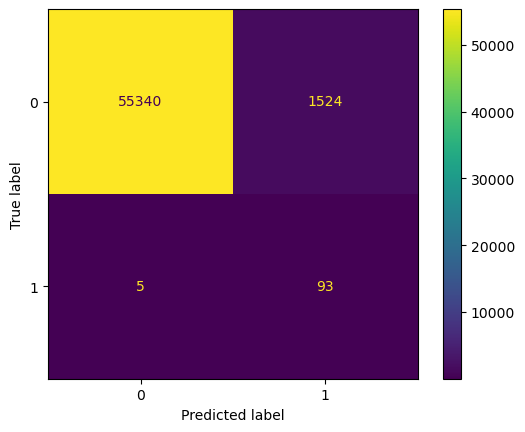

In [51]:
obj = ConfusionMatrixDisplay(cm)
obj.plot()

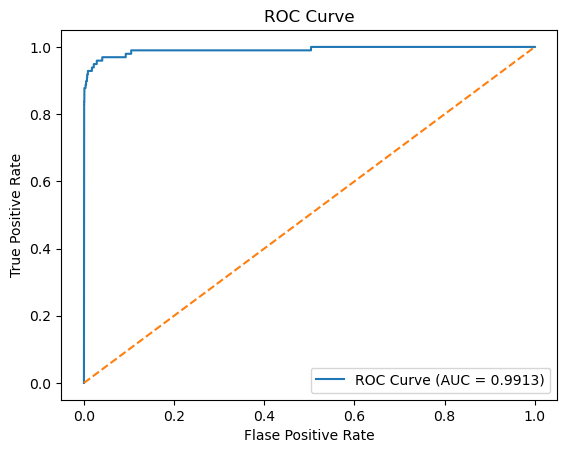

In [52]:
# roc values
fpr,tpr,threshold = roc_curve(y_test,y_prob)

# AUC score

roc_auc = roc_auc_score(y_test,y_prob)

plt.figure()
plt.plot(fpr,tpr,label=f"ROC Curve (AUC = {roc_auc:.4f})")
plt.plot([0,1],[0,1],linestyle='--')
plt.xlabel("Flase Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

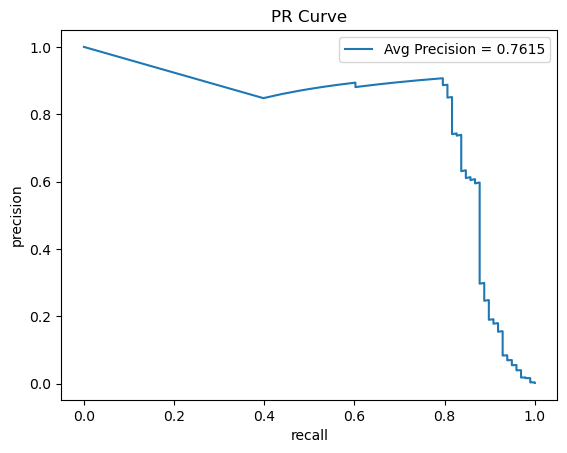

In [53]:
precision , recall , threshold = precision_recall_curve(y_test,y_prob)

avg_prec_score = average_precision_score(y_test,y_prob)

plt.plot(recall,precision,label=f"Avg Precision = {avg_prec_score:.4f}")
plt.xlabel("recall")
plt.ylabel("precision")
plt.title("PR Curve")
plt.legend()
plt.show()

## Random Forest 

In [114]:
## train test split 
X = df.iloc[:,:-1]
y = df.iloc[:,-1]

X_train,X_test,y_train,y_test = train_test_split(X,y,random_state = 2,test_size = 0.2,stratify=y)


In [115]:
from sklearn.ensemble import RandomForestClassifier
rf_01 = RandomForestClassifier(n_estimators=200,n_jobs = -1,random_state=42,warm_start=True)

rf_01.fit(X_train,y_train)

,n_estimators,200
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [133]:
y_prob = rf_01.predict_proba(X_test)[:,1]
y_pred = rf_01.predict(X_test)


Acuracy :  0.9995611109160493
Recall :  0.8163265306122449
Precision :  0.9195402298850575
F1 Score :  0.8648648648648649
ROC-AUC :  0.9724835769986103
[[56857     7]
 [   18    80]]


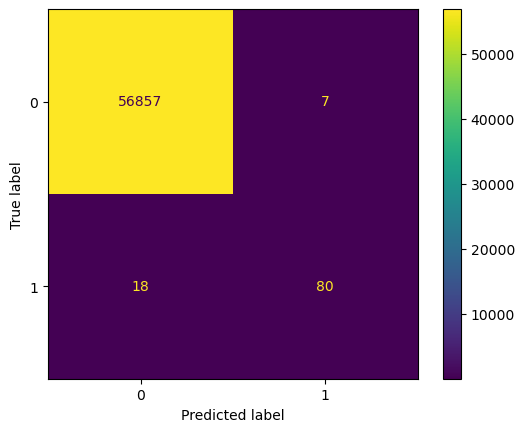

In [134]:
print("Acuracy : ",accuracy_score(y_test,y_pred))
print("Recall : ",recall_score(y_test,y_pred))
print("Precision : ",precision_score(y_test,y_pred))
print("F1 Score : ",f1_score(y_test,y_pred))
print("ROC-AUC : ",roc_auc_score(y_test,y_prob))
cm = confusion_matrix(y_test,y_pred)
print(cm)
obj = ConfusionMatrixDisplay(cm)
obj.plot()

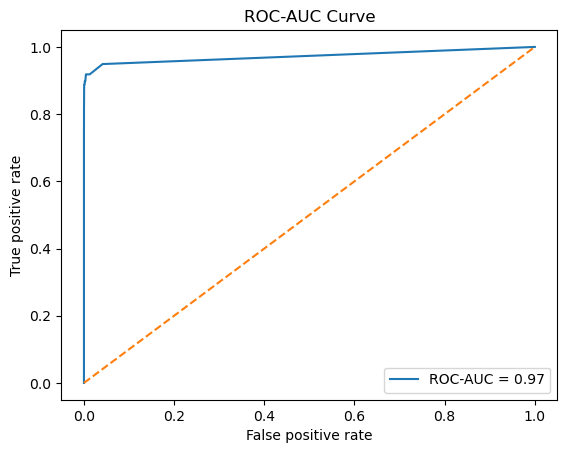

In [135]:
fpr,tpr,threshold = roc_curve(y_test,y_prob)

auc = roc_auc_score(y_test,y_prob)

plt.plot(fpr,tpr,label=f"ROC-AUC = {auc:.2f}")
plt.plot([0,1],[0,1],linestyle='--')
plt.xlabel("False positive rate")
plt.ylabel("True positive rate")
plt.title("ROC-AUC Curve")
plt.legend()
plt.show()

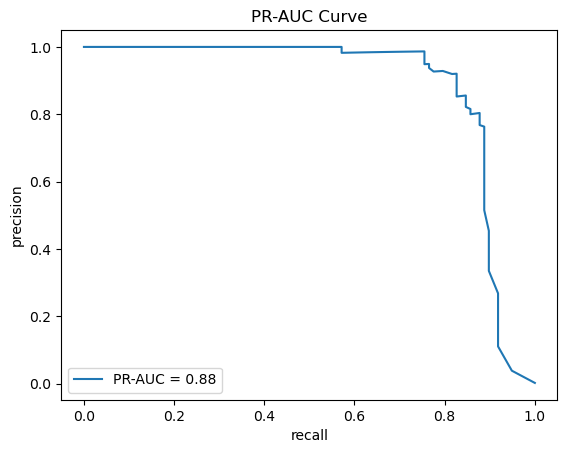

In [137]:
precision , recall,threshold = precision_recall_curve(y_test,y_prob)

avg_precision = average_precision_score(y_test,y_prob)

plt.plot(recall,precision,label=f"PR-AUC = {avg_precision:.2f}")
plt.xlabel("recall")
plt.ylabel("precision")
plt.title("PR-AUC Curve")
plt.legend()
plt.show()

Performing Hyperparameter Tuning

In [139]:
rf_param_grid = {
    "n_estimators":[250,400,500,600],
    "max_depth":[None,5,10,20,30],
    "min_samples_split":[2,5,10,15],
    "min_samples_leaf":[1,2,4,6]
}

In [143]:
from sklearn.model_selection import RandomizedSearchCV

rscv = RandomizedSearchCV(rf_01,rf_param_grid,n_iter=20,scoring='average_precision',n_jobs=-1,refit=True,verbose = 2)

In [144]:
rscv.fit(X_train,y_train)

Fitting 5 folds for each of 20 candidates, totalling 100 fits


,estimator,RandomForestC...rm_start=True)
,param_distributions,"{'max_depth': [None, 5, ...], 'min_samples_leaf': [1, 2, ...], 'min_samples_split': [2, 5, ...], 'n_estimators': [250, 400, ...]}"
,n_iter,20
,scoring,'average_precision'
,n_jobs,-1
,refit,True
,cv,None
,verbose,2
,pre_dispatch,'2*n_jobs'
,random_state,None
,error_score,nan


In [148]:
rscv.best_params_

{'n_estimators': 600,
 'min_samples_split': 2,
 'min_samples_leaf': 1,
 'max_depth': None}

In [149]:
rscv.best_score_

np.float64(0.8349178947147567)

In [212]:
rf_02 = rscv.best_estimator_

In [213]:
y_pred = rf_02.predict(X_test)
y_prob = rf_02.predict_proba(X_test)[:,1]

Acuracy :  0.9995611109160493
Recall :  0.8163265306122449
Precision :  0.9195402298850575
F1 Score :  0.8648648648648649
ROC-AUC :  0.9819644866950719
[[56857     7]
 [   18    80]]


0.88388470125086

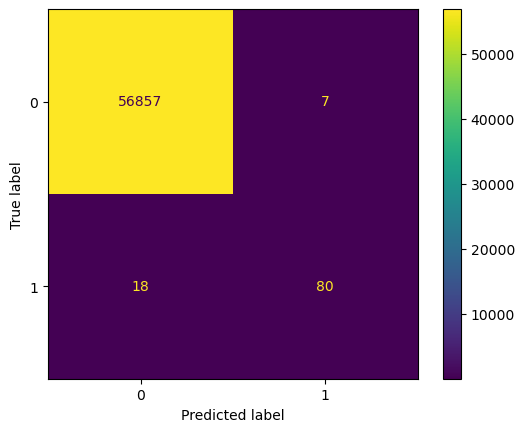

In [214]:
print("Acuracy : ",accuracy_score(y_test,y_pred))
print("Recall : ",recall_score(y_test,y_pred))
print("Precision : ",precision_score(y_test,y_pred))
print("F1 Score : ",f1_score(y_test,y_pred))
print("ROC-AUC : ",roc_auc_score(y_test,y_prob))
cm = confusion_matrix(y_test,y_pred)
print(cm)
obj = ConfusionMatrixDisplay(cm)
obj.plot()
average_precision_score(y_test,y_prob)

In [215]:
results = []

for t in thresholds:
    y_pred_t = (y_prob >= t).astype(int)

    precision = precision_score(y_test, y_pred_t, zero_division=0)
    recall = recall_score(y_test, y_pred_t, zero_division=0)
    f1 = f1_score(y_test, y_pred_t, zero_division=0)

    results.append([t, precision, recall, f1])

threshold_df = pd.DataFrame(
    results,
    columns=["Threshold", "Precision", "Recall", "F1"]
)

threshold_df.head()

,Threshold,Precision,Recall,F1
0,0.10,0.750000,0.887755,0.813084
1,0.11,0.763158,0.887755,0.820755
2,0.12,0.774775,0.877551,0.822967
3,0.13,0.781818,0.877551,0.826923
4,0.14,0.788991,0.877551,0.830918


In [216]:
y_pred_t = (y_prob>=0.16).astype(int)

In [217]:
print("Acuracy : ",accuracy_score(y_test,y_pred_t))
print("Recall : ",recall_score(y_test,y_pred_t))
print("Precision : ",precision_score(y_test,y_pred_t))
print("F1 Score : ",f1_score(y_test,y_pred_t))
print("ROC-AUC : ",roc_auc_score(y_test,y_prob))
confusion_matrix(y_test,y_pred_t)


Acuracy :  0.999420666409185
Recall :  0.8775510204081632
Precision :  0.8037383177570093
F1 Score :  0.8390243902439024
ROC-AUC :  0.9819644866950719


array([[56843,    21],
       [   12,    86]])

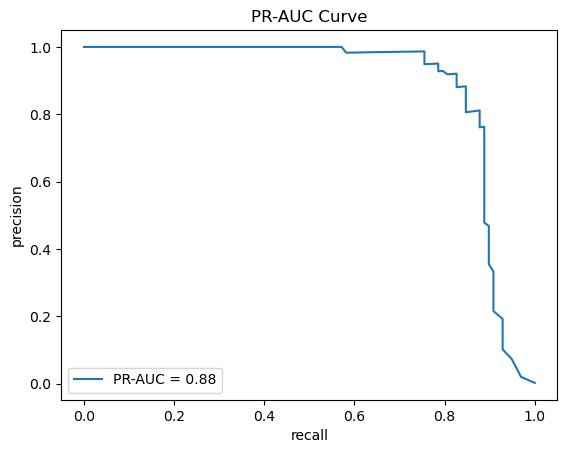

In [218]:
precision , recall,threshold = precision_recall_curve(y_test,y_prob)

avg_precision = average_precision_score(y_test,y_prob)

plt.plot(recall,precision,label=f"PR-AUC = {avg_precision:.2f}")
plt.xlabel("recall")
plt.ylabel("precision")
plt.title("PR-AUC Curve")
plt.legend()
plt.show()

## Gradient Boosting

In [194]:
np.arange(4,11)

array([ 4,  5,  6,  7,  8,  9, 10])

In [196]:
from sklearn.ensemble import GradientBoostingClassifier

gbc_01 = GradientBoostingClassifier(random_state=42,warm_start=True,validation_fraction=0.1,n_iter_no_change=50)

In [191]:
gbc_01.fit(X_train,y_train)


0.0

In [186]:
y_pred = gbc_01.predict(X_test)
y_prob = gbc_01.predict_proba(X_test)[:,1]

Acuracy :  0.999420666409185
Recall :  0.8061224489795918
Precision :  0.8494623655913979
F1 Score :  0.8272251308900523
ROC-AUC :  0.9713609557497733
[[56850    14]
 [   19    79]]


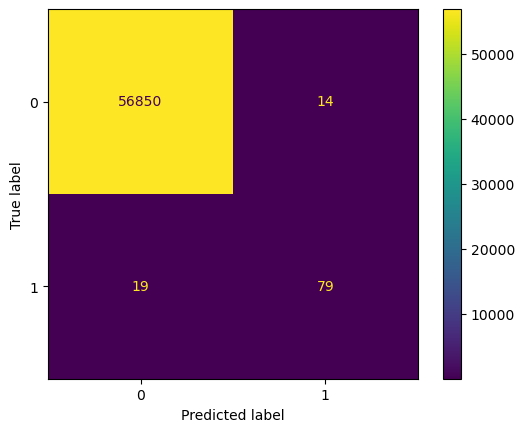

In [187]:

print("Acuracy : ",accuracy_score(y_test,y_pred))
print("Recall : ",recall_score(y_test,y_pred))
print("Precision : ",precision_score(y_test,y_pred))
print("F1 Score : ",f1_score(y_test,y_pred))
print("ROC-AUC : ",roc_auc_score(y_test,y_prob))
cm = confusion_matrix(y_test,y_pred)
print(cm)
obj = ConfusionMatrixDisplay(cm)
obj.plot()

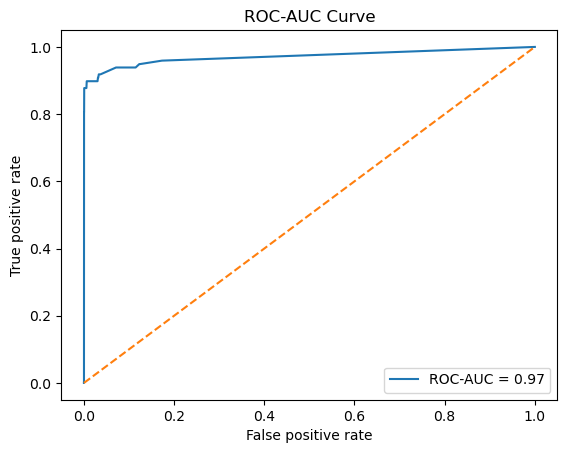

In [188]:
fpr,tpr,threshold = roc_curve(y_test,y_prob)

auc = roc_auc_score(y_test,y_prob)

plt.plot(fpr,tpr,label=f"ROC-AUC = {auc:.2f}")
plt.plot([0,1],[0,1],linestyle='--')
plt.xlabel("False positive rate")
plt.ylabel("True positive rate")
plt.title("ROC-AUC Curve")
plt.legend()
plt.show()

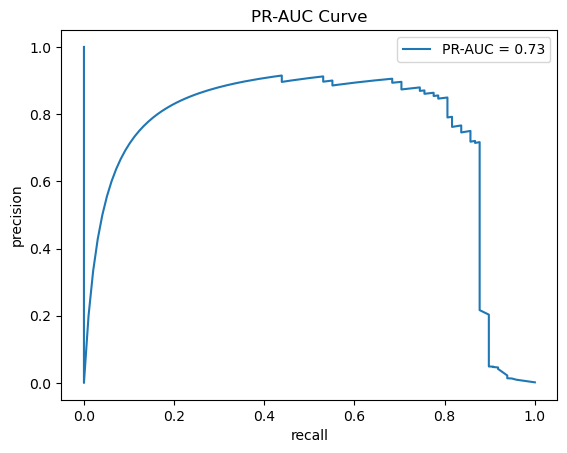

In [189]:
precision , recall,threshold = precision_recall_curve(y_test,y_prob)

avg_precision = average_precision_score(y_test,y_prob)

plt.plot(recall,precision,label=f"PR-AUC = {avg_precision:.2f}")
plt.xlabel("recall")
plt.ylabel("precision")
plt.title("PR-AUC Curve")
plt.legend()
plt.show()

In [197]:
gb_param_grid = {
    "n_estimators": [200,300],
    "learning_rate": [0.01, 0.02, 0.001],
    "max_depth": [4],
    "subsample": [0.8,0.9],
    "min_samples_split":np.arange(4,11)
}

In [198]:
from sklearn.model_selection import GridSearchCV
gscv_gb = GridSearchCV(gbc_01,gb_param_grid,scoring='average_precision',n_jobs=-1,refit=True,verbose=2)

In [199]:
gscv_gb.fit(X_train,y_train)

Fitting 5 folds for each of 84 candidates, totalling 420 fits


,estimator,GradientBoost...rm_start=True)
,param_grid,"{'learning_rate': [0.01, 0.02, ...], 'max_depth': [4], 'min_samples_split': array([ 4, 5..., 8, 9, 10]), 'n_estimators': [200, 300], ...}"
,scoring,'average_precision'
,n_jobs,-1
,refit,True
,cv,None
,verbose,2
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,loss,'log_loss'


In [200]:
gscv_gb.best_score_

np.float64(0.801729313286776)

In [205]:
gscv_gb.best_estimator_

,loss,'log_loss'
,learning_rate,0.001
,n_estimators,300
,subsample,0.8
,criterion,'friedman_mse'
,min_samples_split,np.int64(10)
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_depth,4
,min_impurity_decrease,0.0
,init,None


In [219]:
gbc_02 = gscv_gb.best_estimator_

In [220]:
y_pred = gbc_02.predict(X_test)
y_prob = gbc_02.predict_proba(X_test)[:,1]

Acuracy :  0.9982795547909132
Recall :  0.0
Precision :  0.0
F1 Score :  0.0
ROC-AUC :  0.963299024238283
[[56864     0]
 [   98     0]]


c:\ProgramData\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


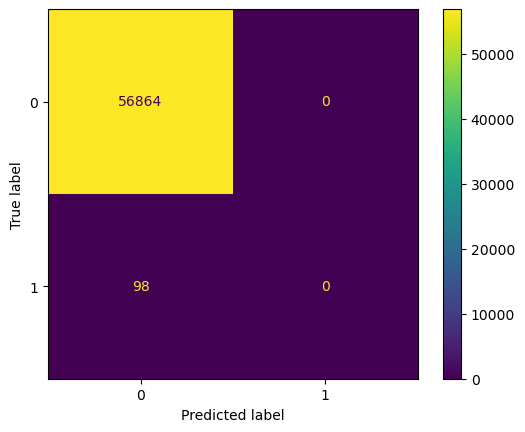

In [221]:

print("Acuracy : ",accuracy_score(y_test,y_pred))
print("Recall : ",recall_score(y_test,y_pred))
print("Precision : ",precision_score(y_test,y_pred))
print("F1 Score : ",f1_score(y_test,y_pred))
print("ROC-AUC : ",roc_auc_score(y_test,y_prob))
cm = confusion_matrix(y_test,y_pred)
print(cm)
obj = ConfusionMatrixDisplay(cm)
obj.plot()

In [222]:
results = []

for t in thresholds:
    y_pred_t = (y_prob >= t).astype(int)

    precision = precision_score(y_test, y_pred_t, zero_division=0)
    recall = recall_score(y_test, y_pred_t, zero_division=0)
    f1 = f1_score(y_test, y_pred_t, zero_division=0)

    results.append([t, precision, recall, f1])

threshold_df = pd.DataFrame(
    results,
    columns=["Threshold", "Precision", "Recall", "F1"]
)

threshold_df.head()

,Threshold,Precision,Recall,F1
0,0.10,0.843750,0.826531,0.835052
1,0.11,0.870968,0.826531,0.848168
2,0.12,0.890110,0.826531,0.857143
3,0.13,0.890110,0.826531,0.857143
4,0.14,0.890110,0.826531,0.857143


In [223]:
y_pred_t = (y_prob>=0.14).astype(int)

print("Acuracy : ",accuracy_score(y_test,y_pred_t))
print("Recall : ",recall_score(y_test,y_pred_t))
print("Precision : ",precision_score(y_test,y_pred_t))
print("F1 Score : ",f1_score(y_test,y_pred_t))
print("ROC-AUC : ",roc_auc_score(y_test,y_prob))
confusion_matrix(y_test,y_pred_t)


Acuracy :  0.9995259997893332
Recall :  0.826530612244898
Precision :  0.8901098901098901
F1 Score :  0.8571428571428571
ROC-AUC :  0.963299024238283


array([[56854,    10],
       [   17,    81]])

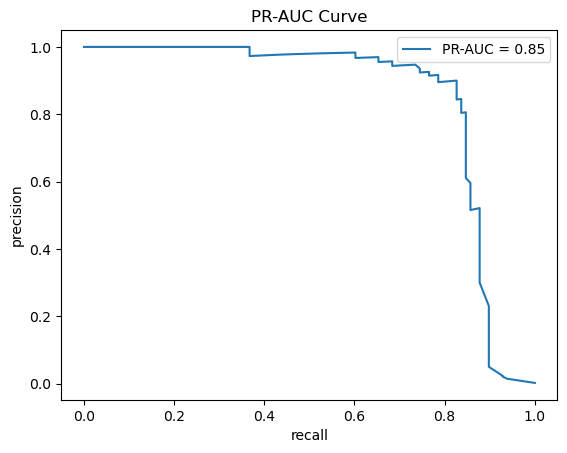

In [242]:
precision , recall,threshold = precision_recall_curve(y_test,y_prob)

avg_precision = average_precision_score(y_test,y_prob)

plt.plot(recall,precision,label=f"PR-AUC = {avg_precision:.2f}")
plt.xlabel("recall")
plt.ylabel("precision")
plt.title("PR-AUC Curve")
plt.legend()
plt.show()

### XGBoost

In [236]:
neg = (y_train == 0).sum()
pos = (y_train == 1).sum()

scale_pos_weight = neg/pos

print(scale_pos_weight)

577.2868020304569


In [237]:
from xgboost import XGBClassifier


In [259]:
xgb = XGBClassifier(
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    n_jobs=-1
)


In [ ]:
xgb.fit(X_train,y_train)

In [ ]:
y_pred_xgb = xgb.predict(X_test)
y_prob_xgb = xgb.predict_proba(X_test)[:,1]

In [256]:

print("Acuracy : ",accuracy_score(y_test,y_pred_xgb))
print("Recall : ",recall_score(y_test,y_pred_xgb))
print("Precision : ",precision_score(y_test,y_pred_xgb))
print("F1 Score : ",f1_score(y_test,y_pred_xgb))
print("ROC-AUC : ",roc_auc_score(y_test,y_prob_xgb))
confusion_matrix(y_test,y_pred_xgb)


Acuracy :  0.9995259997893332
Recall :  0.8469387755102041
Precision :  0.8736842105263158
F1 Score :  0.8601036269430051
ROC-AUC :  0.9905228586932803


array([[56852,    12],
       [   15,    83]])

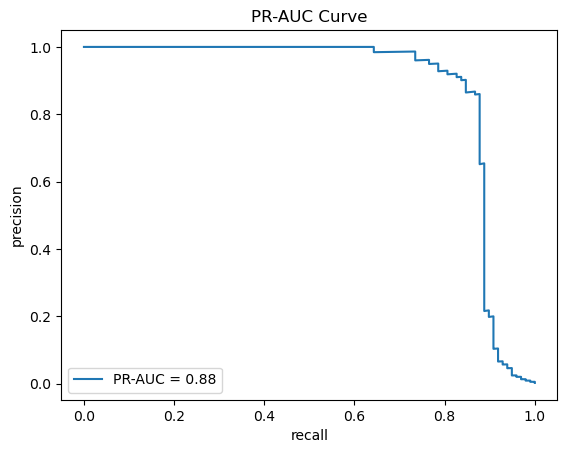

In [257]:
precision , recall,threshold = precision_recall_curve(y_test,y_prob_xgb)

avg_precision = average_precision_score(y_test,y_prob_xgb)

plt.plot(recall,precision,label=f"PR-AUC = {avg_precision:.2f}")
plt.xlabel("recall")
plt.ylabel("precision")
plt.title("PR-AUC Curve")
plt.legend()
plt.show()

In [258]:
results = []

for t in thresholds:
    y_pred_t = (y_prob_xgb >= t).astype(int)

    precision = precision_score(y_test, y_pred_t, zero_division=0)
    recall = recall_score(y_test, y_pred_t, zero_division=0)
    f1 = f1_score(y_test, y_pred_t, zero_division=0)

    results.append([t, precision, recall, f1])

threshold_df = pd.DataFrame(
    results,
    columns=["Threshold", "Precision", "Recall", "F1"]
)

threshold_df.head()

,Threshold,Precision,Recall,F1
0,0.10,0.826923,0.877551,0.851485
1,0.11,0.826923,0.877551,0.851485
2,0.12,0.834951,0.877551,0.855721
3,0.13,0.834951,0.877551,0.855721
4,0.14,0.851485,0.877551,0.864322


In [261]:
param_grid_xgb = {
    'max_depth': [3, 5, 6,7],
    'learning_rate': [0.01, 0.1,0.2,0.4],
    'n_estimators': [100,200,500],
    'subsample': [0.8,0.9, 1.0],
    'colsample_bytree': [0.8, 0.9,1.0]
}

In [262]:
gscv_xgb = GridSearchCV(xgb,param_grid_xgb,scoring='average_precision',refit=True,n_jobs=-1)

In [263]:
gscv_xgb.fit(X_train, y_train)

In [264]:
gscv_xgb.best_score_

np.float64(0.8448689076541551)

In [265]:
gscv_xgb.best_params_

{'colsample_bytree': 0.8,
 'learning_rate': 0.2,
 'max_depth': 7,
 'n_estimators': 500,
 'subsample': 0.9}

In [ ]:
clf = gscv_xgb.best_estimator_ # a copy model of the best params

In [359]:
xgb_02 = XGBClassifier(colsample_bylevel= 0.8,
    learning_rate= 0.3,
    max_depth= 4,
    n_estimators= 200,
    subsample= 0.9,
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    n_jobs=-1
)


In [360]:
xgb_02.fit(X_train,y_train)


,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,0.8
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [361]:
y_pred_xgb_02 = xgb_02.predict(X_test)
y_prob_xgb_02 = xgb_02.predict_proba(X_test)[:,1]
print("Acuracy : ",accuracy_score(y_test,y_pred_xgb_02))
print("Recall : ",recall_score(y_test,y_pred_xgb_02))
print("Precision : ",precision_score(y_test,y_pred_xgb_02))
print("F1 Score : ",f1_score(y_test,y_pred_xgb_02))
print("ROC-AUC : ",roc_auc_score(y_test,y_prob_xgb_02))
print("Average Precision : ",average_precision_score(y_test,y_prob_xgb_02))
confusion_matrix(y_test,y_pred_xgb_02)

Acuracy :  0.9995786664794073
Recall :  0.8673469387755102
Precision :  0.8854166666666666
F1 Score :  0.8762886597938144
ROC-AUC :  0.987219775360904
Average Precision :  0.8848308482914705


array([[56853,    11],
       [   13,    85]])

In [362]:
# dump_list = xgb_02.get_booster().get_dump()
# print(dump_list[1])

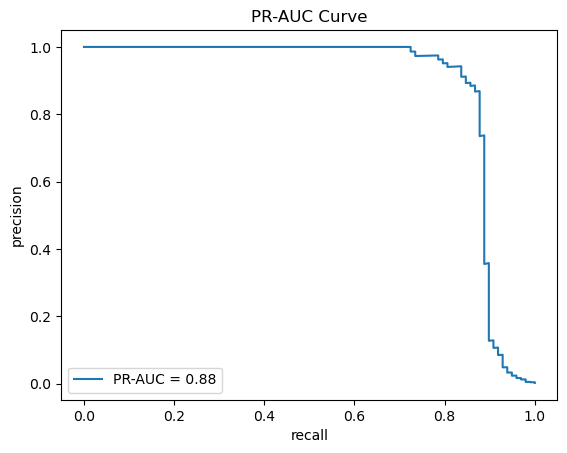

In [363]:
precision , recall,threshold = precision_recall_curve(y_test,y_prob_xgb_02)

avg_precision = average_precision_score(y_test,y_prob_xgb_02)

plt.plot(recall,precision,label=f"PR-AUC = {avg_precision:.2f}")
plt.xlabel("recall")
plt.ylabel("precision")
plt.title("PR-AUC Curve")
plt.legend()
plt.show()

In [364]:
results = []

for t in thresholds:
    y_pred_t = (y_prob_xgb_02 >= t).astype(int)

    precision = precision_score(y_test, y_pred_t, zero_division=0)
    recall = recall_score(y_test, y_pred_t, zero_division=0)
    f1 = f1_score(y_test, y_pred_t, zero_division=0)

    results.append([t, precision, recall, f1])

threshold_df = pd.DataFrame(
    results,
    columns=["Threshold", "Precision", "Recall", "F1"]
)

threshold_df.head()

,Threshold,Precision,Recall,F1
0,0.10,0.811321,0.877551,0.843137
1,0.11,0.811321,0.877551,0.843137
2,0.12,0.811321,0.877551,0.843137
3,0.13,0.819048,0.877551,0.847291
4,0.14,0.843137,0.877551,0.860000


In [365]:
y_pred_t = (y_prob_xgb_02>=0.22).astype(int)

print("Acuracy : ",accuracy_score(y_test,y_pred_t))
print("Recall : ",recall_score(y_test,y_pred_t))
print("Precision : ",precision_score(y_test,y_pred_t))
print("F1 Score : ",f1_score(y_test,y_pred_t))
print("ROC-AUC : ",roc_auc_score(y_test,y_prob_xgb_02))
confusion_matrix(y_test,y_pred_t)


Acuracy :  0.9995259997893332
Recall :  0.8775510204081632
Precision :  0.8514851485148515
F1 Score :  0.864321608040201
ROC-AUC :  0.987219775360904


array([[56849,    15],
       [   12,    86]])

In [ ]:
# XGBoost gives the best result out of all . xgb_02 is the final model with threshold 
# optimization 0.22